## Week 9 Instructor Lab: Winston Caton

In [1]:
# load modules
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts # for QQ plot
from scipy.stats import pearsonr # correlation p-values
from sklearn.linear_model import LinearRegression # regression output
import statsmodels.formula.api as smf # ols regression

os.chdir("c:\\Users\\winst\\OneDrive\\Desktop\\Python 2\\Week9\\week9labs\\data")  # add your filepath within the quotes
os.getcwd()  # confirm change

'c:\\Users\\winst\\OneDrive\\Desktop\\Python 2\\Week9\\week9labs\\data'

In [2]:
# load data
hospitals = pd.read_csv("CaliforniaHospitalData.csv")
personnel = pd.read_csv("CaliforniaHospitalData_Personnel.txt", sep='\t')

In [3]:
##df1.merge(df2, left_on='lkey', right_on='rkey')
merged = personnel.merge(hospitals, left_on = 'HospitalID', right_on = 'HospitalID', how = 'inner', suffixes =('_x', '_y'))
merged

,HospitalID,Work_ID,LastName,FirstName,Gender,PositionID,PositionTitle,Compensation,MaxTerm,StartDate,...,TypeControl,Teaching,DonorType,NoFTE,NetPatRev,InOperExp,OutOperExp,OperRev,OperInc,AvlBeds
0,12145,756481,Rodriguez,Jose,M,1,Regional Representative,46978,4,1/1/2009,...,Non Profit,Small/Rural,Charity,345.0,136156.69130,3.344754e+07,2.034860e+07,53351748,-444391,99
1,45771,756481,Rodriguez,Jose,M,1,Regional Representative,46978,4,1/1/2011,...,District,Small/Rural,Charity,219.0,52983.85792,8.074273e+06,1.299607e+07,19484351,-1585993,76
2,43353,756481,Rodriguez,Jose,M,4,Safety Inspection Member,23987,2,1/1/2011,...,Non Profit,Small/Rural,Charity,55.0,14172.24044,1.436471e+06,3.989894e+06,5235317,-191048,12
3,17718,811240,Charles,Kenneth,M,1,Regional Representative,46978,4,1/1/2009,...,Non Profit,Small/Rural,Charity,215.5,123480.27050,2.200350e+07,2.241005e+07,45769108,1355554,60
4,17736,811240,Charles,Kenneth,M,3,Acting Director,248904,8,1/1/2006,...,Non Profit,Small/Rural,Charity,524.5,295579.23500,5.669283e+07,5.026417e+07,109748000,2791000,121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,33283,704360,Frank,Vernon,M,1,Regional Representative,46978,4,1/1/2012,...,Non Profit,Small/Rural,Charity,353.0,173227.48630,2.864761e+07,3.962144e+07,64464737,-3804313,25
57,33242,704360,Frank,Vernon,M,4,Safety Inspection Member,23987,2,1/1/2011,...,Non Profit,Small/Rural,Charity,318.0,161745.22400,3.064671e+07,3.027761e+07,59669536,-1254783,42
58,46342,768057,Tanner,Patricia,F,3,Acting Director,248904,8,1/1/2011,...,District,Small/Rural,Charity,160.0,65792.42623,1.534131e+07,7.916540e+06,24164520,906670,131
59,43437,768057,Tanner,Patricia,F,1,Regional Representative,46978,4,1/1/2010,...,District,Small/Rural,Charity,121.0,17566.92896,2.890228e+06,4.578888e+06,6677960,-791156,37


In [ ]:
#Adding an additional row of data to the dataframe.

new_rows = pd.DataFrame({'HospitalID': [46342], 
                         'LastName': ['Caton'],
                         'FirstName' : ['Winston'],
                         'Gender' : ['M'],
                         'PositionTitle' : ['Acting Director'],
                         'Compensation' : [248904],
                         'MaxTerm' : [8],
                         'StartDate' : ['4/16/2025'],
                         'Phone' : ['406-212-9869'],
                         'Email' : ['winston.caton@umconnect.umt.edu'],
                         'Name' : ['Coalinga Regional Medical Center'],
                         'Zip' : ['93210'],
                         'TypeControl' : ['District'],
                         'Teaching' : ['Small/Rural'],
                         'DonorType' : ['Charity'],
                         'NoFTE' : [160],
                         'NetPatRev' : [65792.42623],
                         'InOperExp' : [15341310.03],
                         'OutOperExp' : [7916539.968],
                         'OperRev' : [24164520,],
                         'OperInc' : [906670],
                         'AvlBeds' : [131]}, 
                        index = [61]
                       )

## This is the method I used in week 7 Independent Homework- which still doesn't have feedback so I'm curious if there is a quicker way to do this.

In [6]:
new_merge = pd.concat([merged, new_rows], ignore_index = True)
new_merge

,HospitalID,Work_ID,LastName,FirstName,Gender,PositionID,PositionTitle,Compensation,MaxTerm,StartDate,...,TypeControl,Teaching,DonorType,NoFTE,NetPatRev,InOperExp,OutOperExp,OperRev,OperInc,AvlBeds
0,12145,756481.0,Rodriguez,Jose,M,1.0,Regional Representative,46978,4,1/1/2009,...,Non Profit,Small/Rural,Charity,345.0,136156.69130,3.344754e+07,2.034860e+07,53351748,-444391,99
1,45771,756481.0,Rodriguez,Jose,M,1.0,Regional Representative,46978,4,1/1/2011,...,District,Small/Rural,Charity,219.0,52983.85792,8.074273e+06,1.299607e+07,19484351,-1585993,76
2,43353,756481.0,Rodriguez,Jose,M,4.0,Safety Inspection Member,23987,2,1/1/2011,...,Non Profit,Small/Rural,Charity,55.0,14172.24044,1.436471e+06,3.989894e+06,5235317,-191048,12
3,17718,811240.0,Charles,Kenneth,M,1.0,Regional Representative,46978,4,1/1/2009,...,Non Profit,Small/Rural,Charity,215.5,123480.27050,2.200350e+07,2.241005e+07,45769108,1355554,60
4,17736,811240.0,Charles,Kenneth,M,3.0,Acting Director,248904,8,1/1/2006,...,Non Profit,Small/Rural,Charity,524.5,295579.23500,5.669283e+07,5.026417e+07,109748000,2791000,121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,33242,704360.0,Frank,Vernon,M,4.0,Safety Inspection Member,23987,2,1/1/2011,...,Non Profit,Small/Rural,Charity,318.0,161745.22400,3.064671e+07,3.027761e+07,59669536,-1254783,42
58,46342,768057.0,Tanner,Patricia,F,3.0,Acting Director,248904,8,1/1/2011,...,District,Small/Rural,Charity,160.0,65792.42623,1.534131e+07,7.916540e+06,24164520,906670,131
59,43437,768057.0,Tanner,Patricia,F,1.0,Regional Representative,46978,4,1/1/2010,...,District,Small/Rural,Charity,121.0,17566.92896,2.890228e+06,4.578888e+06,6677960,-791156,37
60,29823,768057.0,Tanner,Patricia,F,3.0,Acting Director,248904,8,1/1/2009,...,Non Profit,Small/Rural,Charity,168.0,51726.49180,9.022366e+06,1.040251e+07,19445901,21025,48


In [7]:
#Remove Columns 
new_merge.drop(['Work_ID', 'PositionID', 'Website'], axis = 1)

,HospitalID,LastName,FirstName,Gender,PositionTitle,Compensation,MaxTerm,StartDate,Phone,Email,...,TypeControl,Teaching,DonorType,NoFTE,NetPatRev,InOperExp,OutOperExp,OperRev,OperInc,AvlBeds
0,12145,Rodriguez,Jose,M,Regional Representative,46978,4,1/1/2009,405-744-2238,jose.rodriguez@edihealth.com,...,Non Profit,Small/Rural,Charity,345.0,136156.69130,3.344754e+07,2.034860e+07,53351748,-444391,99
1,45771,Rodriguez,Jose,M,Regional Representative,46978,4,1/1/2011,405-744-2238,jose.rodriguez@edihealth.com,...,District,Small/Rural,Charity,219.0,52983.85792,8.074273e+06,1.299607e+07,19484351,-1585993,76
2,43353,Rodriguez,Jose,M,Safety Inspection Member,23987,2,1/1/2011,405-744-2238,jose.rodriguez@edihealth.com,...,Non Profit,Small/Rural,Charity,55.0,14172.24044,1.436471e+06,3.989894e+06,5235317,-191048,12
3,17718,Charles,Kenneth,M,Regional Representative,46978,4,1/1/2009,405-744-3412,kenneth.charles@edihealth.com,...,Non Profit,Small/Rural,Charity,215.5,123480.27050,2.200350e+07,2.241005e+07,45769108,1355554,60
4,17736,Charles,Kenneth,M,Acting Director,248904,8,1/1/2006,405-744-3412,kenneth.charles@edihealth.com,...,Non Profit,Small/Rural,Charity,524.5,295579.23500,5.669283e+07,5.026417e+07,109748000,2791000,121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,33242,Frank,Vernon,M,Safety Inspection Member,23987,2,1/1/2011,801-687-2845,vernon.frank@ihc.com,...,Non Profit,Small/Rural,Charity,318.0,161745.22400,3.064671e+07,3.027761e+07,59669536,-1254783,42
58,46342,Tanner,Patricia,F,Acting Director,248904,8,1/1/2011,801-687-7877,patricia.tanner@prohealth.net,...,District,Small/Rural,Charity,160.0,65792.42623,1.534131e+07,7.916540e+06,24164520,906670,131
59,43437,Tanner,Patricia,F,Regional Representative,46978,4,1/1/2010,801-687-7877,patricia.tanner@prohealth.net,...,District,Small/Rural,Charity,121.0,17566.92896,2.890228e+06,4.578888e+06,6677960,-791156,37
60,29823,Tanner,Patricia,F,Acting Director,248904,8,1/1/2009,801-687-7877,patricia.tanner@prohealth.net,...,Non Profit,Small/Rural,Charity,168.0,51726.49180,9.022366e+06,1.040251e+07,19445901,21025,48


In [ ]:
## Converting Date-Time columns into a datetime data type.
new_merge['StartDate'] = pd.to_datetime(new_merge['StartDate'])
new_merge

,HospitalID,Work_ID,LastName,FirstName,Gender,PositionID,PositionTitle,Compensation,MaxTerm,StartDate,...,TypeControl,Teaching,DonorType,NoFTE,NetPatRev,InOperExp,OutOperExp,OperRev,OperInc,AvlBeds
0,12145,756481.0,Rodriguez,Jose,M,1.0,Regional Representative,46978,4,2009-01-01,...,Non Profit,Small/Rural,Charity,345.0,136156.69130,3.344754e+07,2.034860e+07,53351748,-444391,99
1,45771,756481.0,Rodriguez,Jose,M,1.0,Regional Representative,46978,4,2011-01-01,...,District,Small/Rural,Charity,219.0,52983.85792,8.074273e+06,1.299607e+07,19484351,-1585993,76
2,43353,756481.0,Rodriguez,Jose,M,4.0,Safety Inspection Member,23987,2,2011-01-01,...,Non Profit,Small/Rural,Charity,55.0,14172.24044,1.436471e+06,3.989894e+06,5235317,-191048,12
3,17718,811240.0,Charles,Kenneth,M,1.0,Regional Representative,46978,4,2009-01-01,...,Non Profit,Small/Rural,Charity,215.5,123480.27050,2.200350e+07,2.241005e+07,45769108,1355554,60
4,17736,811240.0,Charles,Kenneth,M,3.0,Acting Director,248904,8,2006-01-01,...,Non Profit,Small/Rural,Charity,524.5,295579.23500,5.669283e+07,5.026417e+07,109748000,2791000,121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,33242,704360.0,Frank,Vernon,M,4.0,Safety Inspection Member,23987,2,2011-01-01,...,Non Profit,Small/Rural,Charity,318.0,161745.22400,3.064671e+07,3.027761e+07,59669536,-1254783,42
58,46342,768057.0,Tanner,Patricia,F,3.0,Acting Director,248904,8,2011-01-01,...,District,Small/Rural,Charity,160.0,65792.42623,1.534131e+07,7.916540e+06,24164520,906670,131
59,43437,768057.0,Tanner,Patricia,F,1.0,Regional Representative,46978,4,2010-01-01,...,District,Small/Rural,Charity,121.0,17566.92896,2.890228e+06,4.578888e+06,6677960,-791156,37
60,29823,768057.0,Tanner,Patricia,F,3.0,Acting Director,248904,8,2009-01-01,...,Non Profit,Small/Rural,Charity,168.0,51726.49180,9.022366e+06,1.040251e+07,19445901,21025,48


In [12]:
## Convert TypeControl, Teaching, DonorType and Gender to Categorical data type

new_merge['TypeControl_categorical'] = new_merge['TypeControl'].astype('category')
new_merge['Teaching_categorical'] = new_merge['Teaching'].astype('category')
new_merge['DonorType_categorical'] = new_merge['DonorType'].astype('category')
new_merge['Gender_categorical'] = new_merge['Gender'].astype('category')
new_merge.dtypes

HospitalID                          int64
Work_ID                           float64
LastName                           object
FirstName                          object
Gender                             object
PositionID                        float64
PositionTitle                      object
Compensation                        int64
MaxTerm                             int64
StartDate                  datetime64[ns]
Phone                              object
Email                              object
Name                               object
Zip                                object
Website                            object
TypeControl                        object
Teaching                           object
DonorType                          object
NoFTE                             float64
NetPatRev                         float64
InOperExp                         float64
OutOperExp                        float64
OperRev                             int64
OperInc                           

## Descriptive Statistics

In [27]:
new_merge.describe(include=['number'])

,HospitalID,Work_ID,PositionID,Compensation,MaxTerm,NoFTE,NetPatRev,InOperExp,OutOperExp,OperRev,OperInc,AvlBeds
count,62.000000,61.000000,61.000000,62.000000,62.000000,62.000000,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,62.000000
mean,32062.548387,601906.213115,2.245902,95292.935484,4.306452,1331.066452,6.598450e+05,1.638362e+08,8.883161e+07,2.525296e+08,-1.382197e+05,193.500000
std,11077.730064,242778.066078,1.192417,86160.789603,2.146967,2014.296167,1.091178e+06,2.811143e+08,1.365597e+08,4.225168e+08,7.095584e+07,220.154994
min,10767.000000,229849.000000,1.000000,23987.000000,2.000000,55.000000,1.417224e+04,1.436471e+06,3.787718e+06,5.235317e+06,-3.211633e+08,12.000000
25%,21335.000000,363672.000000,1.000000,46978.000000,3.000000,198.625000,6.579243e+04,1.382645e+07,1.425996e+07,2.416452e+07,-1.028922e+06,42.750000
50%,33267.000000,664583.000000,2.000000,46978.000000,4.000000,368.660000,1.670720e+05,3.124469e+07,3.259692e+07,6.153388e+07,1.464124e+06,100.500000
75%,39108.000000,811240.000000,3.000000,89473.000000,4.000000,1137.000000,5.317051e+05,1.639284e+08,8.867309e+07,1.982414e+08,6.146421e+06,228.250000
max,46996.000000,966527.000000,4.000000,248904.000000,8.000000,8000.000000,4.662582e+06,1.285631e+09,6.621559e+08,1.912179e+09,1.648724e+08,909.000000


In [28]:
new_merge.describe(include=['object'])

,LastName,FirstName,Gender,PositionTitle,Phone,Email,Name,Zip,Website,TypeControl,Teaching,DonorType
count,62,62,62,62,62,62,62,62,61,62,62,62
unique,24,20,2,4,25,25,61,61,60,4,2,2
top,Smith,David,F,Regional Representative,405-744-2238,jose.rodriguez@edihealth.com,Coalinga Regional Medical Center,93210,www.sbch.org,Non Profit,Small/Rural,Charity
freq,4,6,32,24,3,3,2,2,2,37,45,45


In [31]:
new_merge.describe(include=['category'])

,TypeControl_categorical,Teaching_categorical,DonorType_categorical,Gender_categorical
count,62,62,62,62
unique,4,2,2,2
top,Non Profit,Small/Rural,Charity,F
freq,37,45,45,32


<Axes: ylabel='Frequency'>

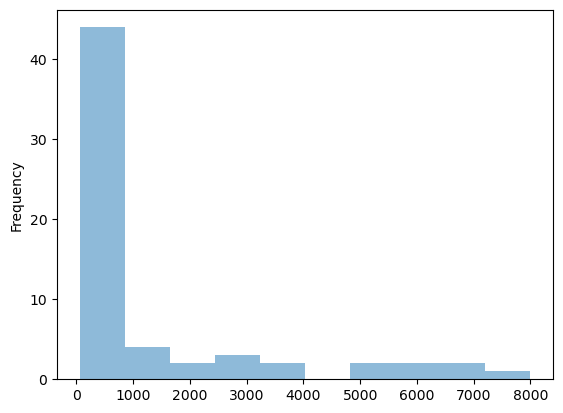

In [14]:
## Histograms for NoFTE, NetPatRev, InOperExp, OutOperExp, OperRev, OperInc, AvlBeds
new_merge['NoFTE'].plot.hist(alpha=0.5)


<Axes: ylabel='Frequency'>

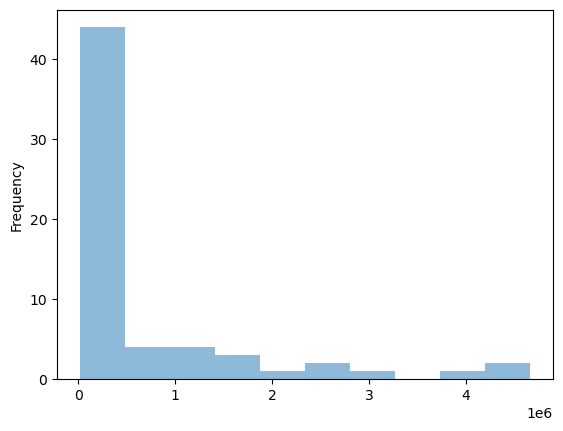

In [15]:
new_merge['NetPatRev'].plot.hist(alpha=0.5)


<Axes: ylabel='Frequency'>

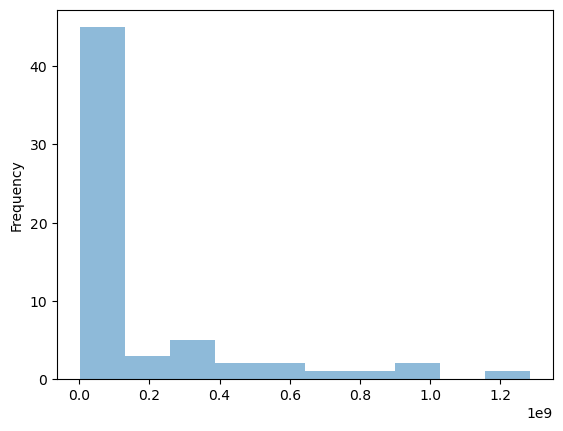

In [16]:
new_merge['InOperExp'].plot.hist(alpha=0.5)


<Axes: ylabel='Frequency'>

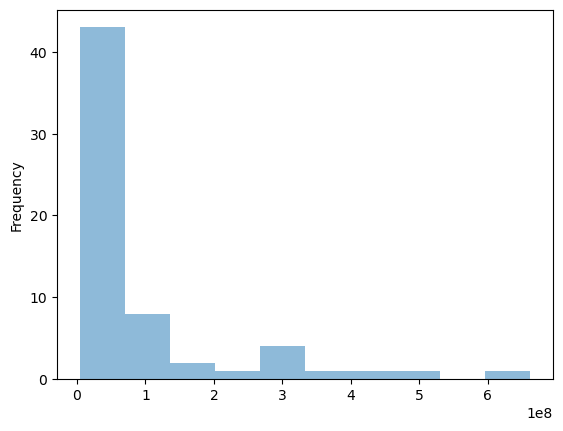

In [17]:
new_merge['OutOperExp'].plot.hist(alpha=0.5)


<Axes: ylabel='Frequency'>

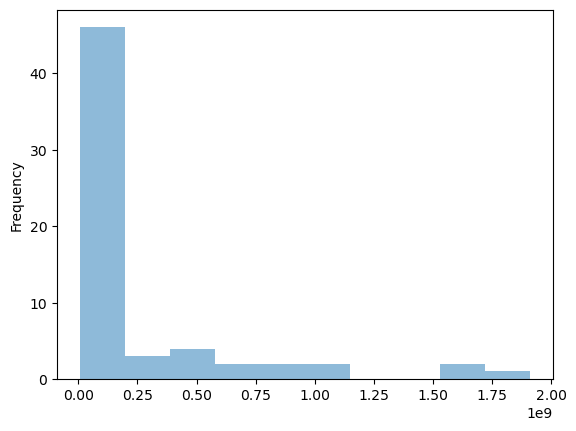

In [18]:
new_merge['OperRev'].plot.hist(alpha=0.5)


<Axes: ylabel='Frequency'>

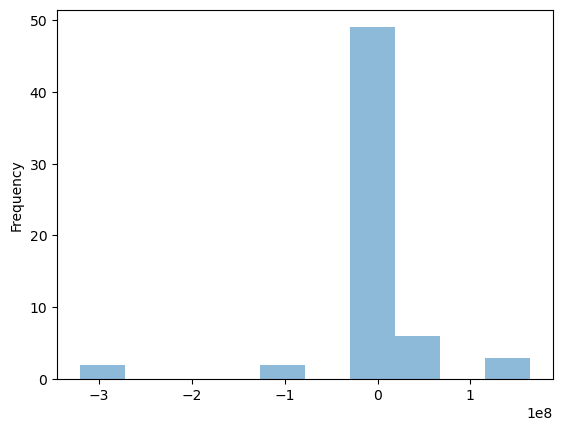

In [19]:
new_merge['OperInc'].plot.hist(alpha=0.5)


<Axes: ylabel='Frequency'>

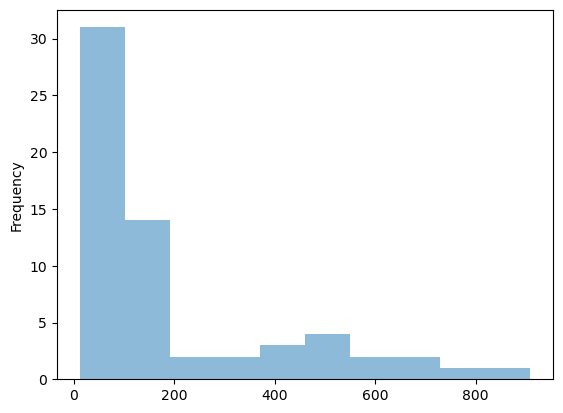

In [20]:
new_merge['AvlBeds'].plot.hist(alpha=0.5)

<Axes: xlabel='NoFTE', ylabel='NetPatRev'>

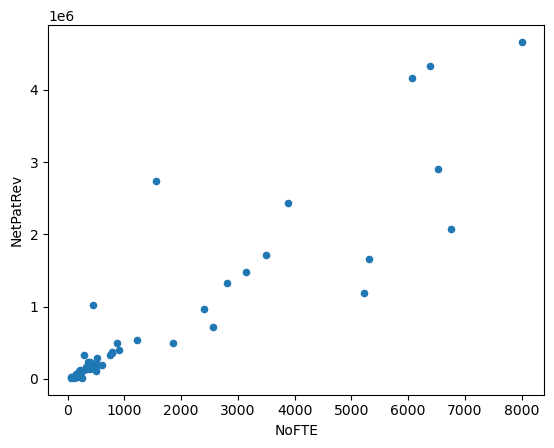

In [21]:
new_merge.plot.scatter(x='NoFTE', y='NetPatRev')

This is a linear relationship, with some outliers well above and below where a best fit line would be.

<Axes: xlabel='InOperExp', ylabel='NetPatRev'>

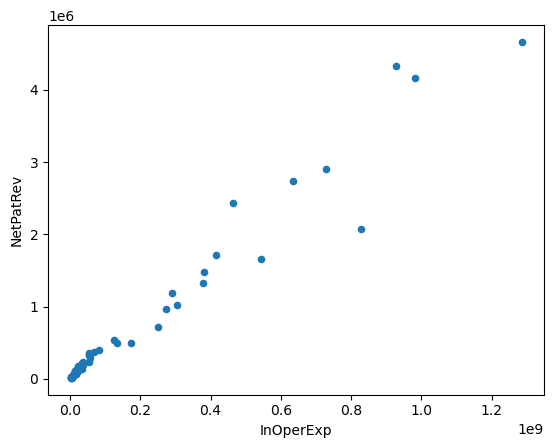

In [22]:
new_merge.plot.scatter(x='InOperExp', y='NetPatRev')

This is a very linear relationship, with less outliers than the previous example but still noticeable outliers.

<Axes: xlabel='OutOperExp', ylabel='NetPatRev'>

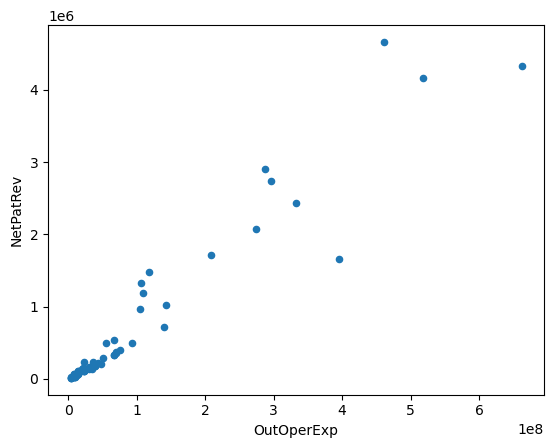

In [23]:
new_merge.plot.scatter(x='OutOperExp', y='NetPatRev')

Another linear relationship is visible here, with a few notable outliers.

<Axes: xlabel='OperRev', ylabel='NetPatRev'>

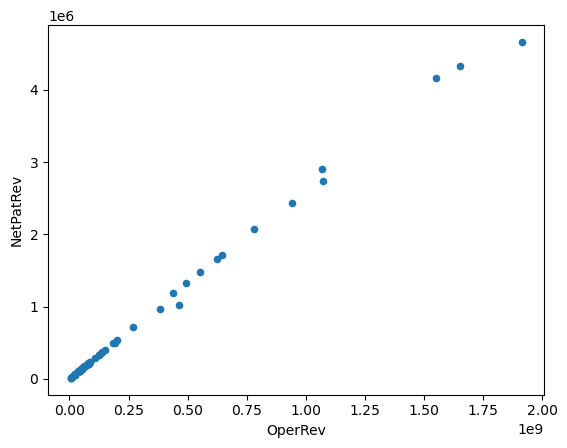

In [24]:
new_merge.plot.scatter(x='OperRev', y='NetPatRev')

This is almost a perfect linear relationship with a correlation close to 1.

<Axes: xlabel='OperInc', ylabel='NetPatRev'>

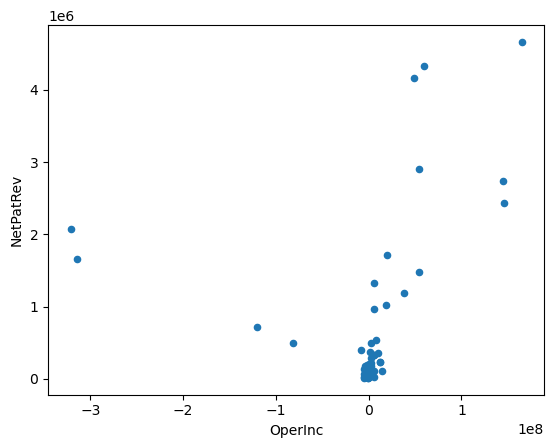

In [25]:
new_merge.plot.scatter(x='OperInc', y='NetPatRev')

Relationship doesn't appear linear, maybe there could be a linear relationship seen if negative operating income hospitals were excluded but it is less clear.

<Axes: xlabel='AvlBeds', ylabel='NetPatRev'>

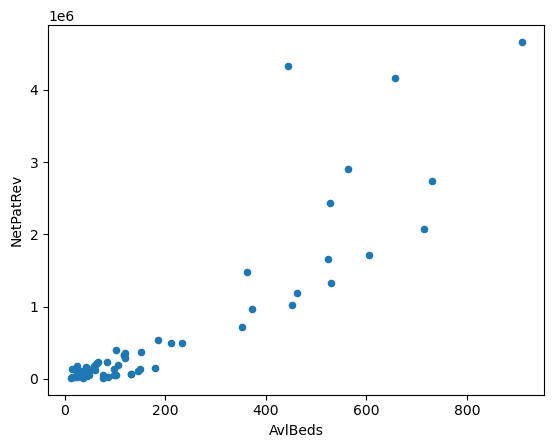

In [26]:
new_merge.plot.scatter(x='AvlBeds', y='NetPatRev')

Appears like a very linear relationship here between beds and revenue, with a few noticeable outliers.

## Boxplots for NoFTE, NetPatRev, InOperExp, OutOperExp, OperRev, OperInc and AvlBeds

<Axes: >

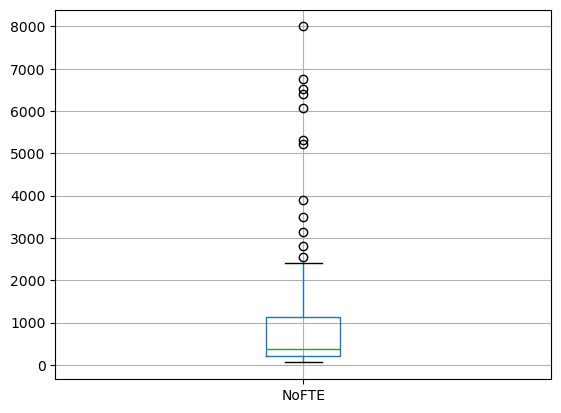

In [39]:
new_merge.loc[:,['NoFTE']].boxplot()

<Axes: >

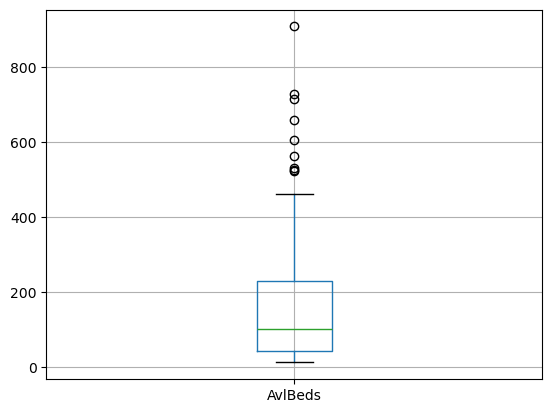

In [40]:
new_merge.loc[:,['AvlBeds']].boxplot()

<Axes: >

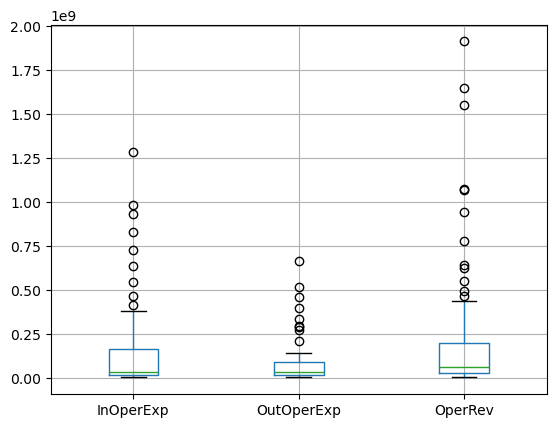

In [41]:
new_merge.loc[:,['InOperExp','OutOperExp','OperRev']].boxplot()

<Axes: >

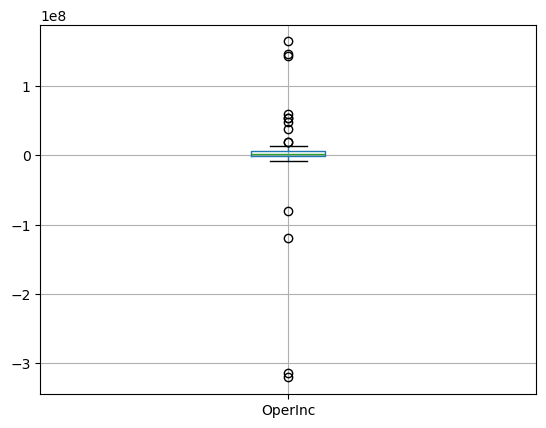

In [42]:
new_merge.loc[:,['OperInc']].boxplot()

<Axes: >

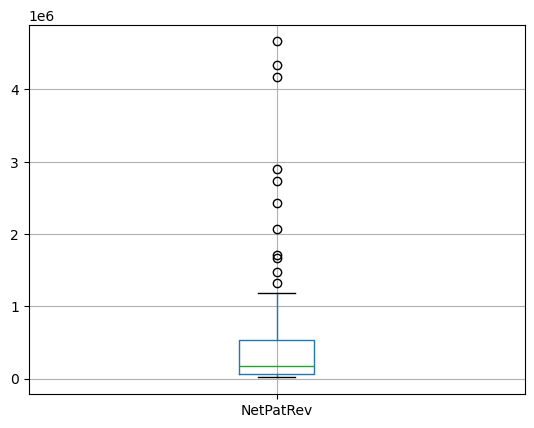

In [43]:
new_merge.loc[:,['NetPatRev']].boxplot()

All of these seven variables have outliers that lie above the boxplot whiskers, and OperInc also has outliers that lie below the bottom of the boxplot whisker due to negative operating income.

In [45]:
## QQ Plot
lin_reg = smf.ols('OperInc ~ NoFTE + AvlBeds', new_merge).fit()


((array([-2.28632824, -1.92718526, -1.71674477, -1.56281938, -1.43895118,
         -1.33390917, -1.24182024, -1.15920615, -1.08382718, -1.01415101,
         -0.94907991, -0.88779833, -0.82968216, -0.77424185, -0.72108527,
         -0.6698925 , -0.6203983 , -0.57237956, -0.52564609, -0.48003374,
         -0.43539923, -0.39161603, -0.34857126, -0.30616308, -0.26429872,
         -0.2228927 , -0.18186549, -0.14114226, -0.10065186, -0.06032587,
         -0.02009779,  0.02009779,  0.06032587,  0.10065186,  0.14114226,
          0.18186549,  0.2228927 ,  0.26429872,  0.30616308,  0.34857126,
          0.39161603,  0.43539923,  0.48003374,  0.52564609,  0.57237956,
          0.6203983 ,  0.6698925 ,  0.72108527,  0.77424185,  0.82968216,
          0.88779833,  0.94907991,  1.01415101,  1.08382718,  1.15920615,
          1.24182024,  1.33390917,  1.43895118,  1.56281938,  1.71674477,
          1.92718526,  2.28632824]),
  array([-3.07136876e+08, -2.95525232e+08, -1.23034738e+08, -7.46345469e+07

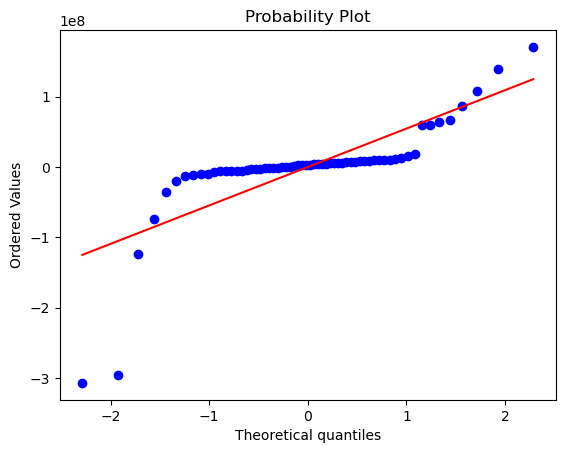

In [47]:
sts.probplot(lin_reg.resid, dist="norm", plot=plt)

There appears to be some wave happening here, and the relationship doesn't appear linear, iand therefore isn't normal either.

In [48]:
sts.shapiro(new_merge.OperInc)

ShapiroResult(statistic=0.5553751226301195, pvalue=2.029808754878887e-12)

Based on this Shapiro-Wilk test, the data is not normally distributed.  This matches with what was determined from the QQ plot as well.

I used this Chat GPT prompt to assist with this assignment: https://chatgpt.com/share/6812f02d-aa2c-800d-a537-557c82bd9cda